# Bitcoin Market Sentiment and Trader Performance Analysis

## Project Objective

The objective of this project is to analyse the relationship between Bitcoin market sentiment and trader performance.

The project combines historical trading data from Hyperliquid with the Bitcoin Fear and Greed Index.

The analysis will explore trader profitability, win rate, leverage, position size, trade direction and behaviour during different market sentiment conditions.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir() and (CURRENT_DIR / "data").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif CURRENT_DIR.name == "notebooks" and (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = next(
        path
        for path in [CURRENT_DIR, *CURRENT_DIR.parents]
        if (path / "src").is_dir() and (path / "data" / "raw").is_dir()
    )

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
CHARTS_DIR = PROJECT_ROOT / "outputs" / "charts"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"

HISTORICAL_DATASET = RAW_DATA_DIR / "historical_data.csv"
FEAR_GREED_DATASET = RAW_DATA_DIR / "fear_greed_index.csv"

project_paths = {
    "Project root": PROJECT_ROOT,
    "Raw data folder": RAW_DATA_DIR,
    "Processed data folder": PROCESSED_DATA_DIR,
    "Charts folder": CHARTS_DIR,
    "Reports folder": REPORTS_DIR,
    "Historical dataset": HISTORICAL_DATASET,
    "Fear and Greed dataset": FEAR_GREED_DATASET,
}

for name, path in project_paths.items():
    print(f"{name}: {path.resolve()}")

Project root: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis
Raw data folder: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\raw
Processed data folder: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\processed
Charts folder: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts
Reports folder: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports
Historical dataset: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\raw\historical_data.csv
Fear and Greed dataset: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\raw\fear_greed_index.csv


# Phase 2: Dataset Loading and Initial Inspection

In this phase, both datasets are loaded and inspected.

No cleaning, merging or transformation is performed in this phase.

In [3]:
import sys
from pathlib import Path

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir() and (CURRENT_DIR / "data").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif CURRENT_DIR.name == "notebooks" and (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = next(
        path
        for path in [CURRENT_DIR, *CURRENT_DIR.parents]
        if (path / "src").is_dir() and (path / "data" / "raw").is_dir()
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data_loader import (
    HISTORICAL_EXPECTED_COLUMNS,
    SENTIMENT_EXPECTED_COLUMNS,
    inspect_dataframe,
    load_project_datasets,
    show_unique_values,
    validate_columns,
)

In [4]:
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

HISTORICAL_DATA_PATH = RAW_DATA_DIR / "historical_data.csv"
SENTIMENT_DATA_PATH = RAW_DATA_DIR / "fear_greed_index.csv"

print(f"Historical data path: {HISTORICAL_DATA_PATH.resolve()}")
print(f"Sentiment data path: {SENTIMENT_DATA_PATH.resolve()}")

Historical data path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\raw\historical_data.csv
Sentiment data path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\raw\fear_greed_index.csv


In [5]:
historical_df, sentiment_df = load_project_datasets(
    HISTORICAL_DATA_PATH,
    SENTIMENT_DATA_PATH,
)

Loaded historical_data.csv successfully: 211224 rows, 16 columns.
Loaded fear_greed_index.csv successfully: 2644 rows, 4 columns.


In [6]:
print("shape = number of rows and columns")
print(f"Historical dataset shape: {historical_df.shape}")
print(f"Sentiment dataset shape: {sentiment_df.shape}")

shape = number of rows and columns
Historical dataset shape: (211224, 16)
Sentiment dataset shape: (2644, 4)


In [7]:
inspect_dataframe(
    historical_df,
    "Historical Trader Data",
)


Dataset Inspection: Historical Trader Data

First five rows:
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                             


Duplicate rows:
0

Summary statistics for numerical columns:
       Execution Price   Size Tokens      Size USD  Start Position  \
count    211224.000000  2.112240e+05  2.112240e+05    2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   -2.994625e+04   
std       29447.654868  1.042729e+05  3.657514e+04    6.738074e+05   
min           0.000005  8.740000e-07  0.000000e+00   -1.433463e+07   
25%           4.854700  2.940000e+00  1.937900e+02   -3.762311e+02   
50%          18.280000  3.200000e+01  5.970450e+02    8.472793e+01   
75%         101.580000  1.879025e+02  2.058960e+03    9.337278e+03   
max      109004.000000  1.582244e+07  3.921431e+06    3.050948e+07   

          Closed PnL      Order ID            Fee      Trade ID     Timestamp  
count  211224.000000  2.112240e+05  211224.000000  2.112240e+05  2.112240e+05  
mean       48.749001  6.965388e+10       1.163967  5.628549e+14  1.737744e+12  
std       919.164828  1.835753e+10       6.758854  3.257565e+14  8.

                                           Account    Coin    Side  \
count                                       211224  211224  211224   
unique                                          32     246       2   
top     0xbee1707d6b44d4d52bfe19e41f8a828645437aab    HYPE    SELL   
freq                                         40184   68005  108528   

           Timestamp IST  Direction  \
count             211224     211224   
unique             27977         12   
top     14-02-2025 00:31  Open Long   
freq                 441      49895   

                                         Transaction Hash  
count                                              211224  
unique                                             101184  
top     0x00000000000000000000000000000000000000000000...  
freq                                                 9032  

Memory usage:
52.64 MB

Is the DataFrame empty?
False


In [8]:
inspect_dataframe(
    sentiment_df,
    "Fear and Greed Index",
)


Dataset Inspection: Fear and Greed Index

First five rows:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05

Last five rows:
       timestamp  value classification        date
2639  1745818200     54        Neutral  2025-04-28
2640  1745904600     60          Greed  2025-04-29
2641  1745991000     56          Greed  2025-04-30
2642  1746077400     53        Neutral  2025-05-01
2643  1746163800     67          Greed  2025-05-02

Dataset size:
Rows: 2644
Columns: 4

Complete column list:
['timestamp', 'value', 'classification', 'date']

Data types:
timestamp         int64
value             int64
classification      str
date                str
dtype: object

Missing-value count:
timestamp         0
value             0
classification    0
date           

In [9]:
validate_columns(
    historical_df,
    HISTORICAL_EXPECTED_COLUMNS,
    "Historical Trader Data",
)


Column Validation: Historical Trader Data

Expected columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Actual columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Missing expected columns:
None

Additional unexpected columns:
None

All expected columns are present.


In [10]:
validate_columns(
    sentiment_df,
    SENTIMENT_EXPECTED_COLUMNS,
    "Fear and Greed Index",
)


Column Validation: Fear and Greed Index

Expected columns:
['timestamp', 'value', 'classification', 'date']

Actual columns:
['timestamp', 'value', 'classification', 'date']

Missing expected columns:
None

Additional unexpected columns:
None

All expected columns are present.


## Important Categorical Values

The following cells inspect important categories such as cryptocurrencies, trade sides, trade directions and market sentiment labels.

In [11]:
show_unique_values(historical_df, "Coin")


Unique Values: Coin

Number of unique values including missing values: 246

First 20 unique values:
['@107', 'AAVE', 'DYDX', 'AIXBT', 'GMX', 'EIGEN', 'HYPE', 'SOL', 'SUI', 'DOGE', 'ETH', 'kPEPE', 'TRUMP', 'ONDO', 'ENA', 'LINK', 'XRP', 'S', 'BNB', 'BERA']

Value counts, including missing values, limited to 20:
Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
TRUMP         1920
XRP           1774
kPEPE         1730
kBONK         1647
FTT           1560
ONDO          1463
@142          1309
PAXG          1265
ZRO           1239
PURR          1198
Name: count, dtype: int64


In [12]:
show_unique_values(historical_df, "Side")


Unique Values: Side

Number of unique values including missing values: 2

First 20 unique values:
['BUY', 'SELL']

Value counts, including missing values, limited to 20:
Side
SELL    108528
BUY     102696
Name: count, dtype: int64


In [13]:
show_unique_values(historical_df, "Direction")


Unique Values: Direction

Number of unique values including missing values: 12

First 20 unique values:
['Buy', 'Sell', 'Open Long', 'Close Long', 'Spot Dust Conversion', 'Open Short', 'Close Short', 'Long > Short', 'Short > Long', 'Auto-Deleveraging', 'Liquidated Isolated Short', 'Settlement']

Value counts, including missing values, limited to 20:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64


In [14]:
show_unique_values(historical_df, "Crossed")


Unique Values: Crossed

Number of unique values including missing values: 2

First 20 unique values:
[True, False]

Value counts, including missing values, limited to 20:
Crossed
True     128403
False     82821
Name: count, dtype: int64


In [15]:
show_unique_values(sentiment_df, "classification")


Unique Values: classification

Number of unique values including missing values: 5

First 20 unique values:
['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed']

Value counts, including missing values, limited to 20:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


## Phase 2 Notes

At this stage:

- Both datasets have been loaded.
- Their structure and columns have been inspected.
- Missing values and duplicate rows have been identified.
- Important categorical values have been reviewed.
- No data has been cleaned or modified yet.

# Phase 3: Data Cleaning and Preparation

In this phase, cleaned copies of both datasets are prepared and saved.

The raw datasets are not modified, and no merging, analysis, charts or conclusions are created in this phase.

In [16]:
from src.data_cleaning import (
    clean_historical_data,
    clean_sentiment_data,
    save_processed_dataset,
)

In [17]:
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

HISTORICAL_DATA_PATH = RAW_DATA_DIR / "historical_data.csv"
SENTIMENT_DATA_PATH = RAW_DATA_DIR / "fear_greed_index.csv"

HISTORICAL_CLEANED_PATH = PROCESSED_DATA_DIR / "historical_data_cleaned.csv"
SENTIMENT_CLEANED_PATH = PROCESSED_DATA_DIR / "fear_greed_index_cleaned.csv"

print(f"Raw historical data path: {HISTORICAL_DATA_PATH.resolve()}")
print(f"Raw sentiment data path: {SENTIMENT_DATA_PATH.resolve()}")
print(f"Cleaned historical data path: {HISTORICAL_CLEANED_PATH.resolve()}")
print(f"Cleaned sentiment data path: {SENTIMENT_CLEANED_PATH.resolve()}")

Raw historical data path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\raw\historical_data.csv
Raw sentiment data path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\raw\fear_greed_index.csv
Cleaned historical data path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\processed\historical_data_cleaned.csv
Cleaned sentiment data path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\processed\fear_greed_index_cleaned.csv


In [18]:
historical_raw_df, sentiment_raw_df = load_project_datasets(
    HISTORICAL_DATA_PATH,
    SENTIMENT_DATA_PATH,
)

Loaded historical_data.csv successfully: 211224 rows, 16 columns.
Loaded fear_greed_index.csv successfully: 2644 rows, 4 columns.


In [19]:
print("Before cleaning:")
print(f"Historical raw shape: {historical_raw_df.shape}")
print(f"Sentiment raw shape: {sentiment_raw_df.shape}")

Before cleaning:
Historical raw shape: (211224, 16)
Sentiment raw shape: (2644, 4)


In [20]:
historical_cleaned_df = clean_historical_data(historical_raw_df)


Cleaning Dataset: Historical Trader Data
Shape before cleaning: (211224, 16)


Historical Trader Data duplicate rows before cleaning: 0


Historical Trader Data duplicate rows removed: 0


Historical Trader Data datetime column converted: timestamp_ist (0 missing values after conversion)
Historical Trader Data datetime column converted: timestamp (0 missing values after conversion)
Historical Trader Data numeric column converted: execution_price (0 missing values after conversion)
Historical Trader Data numeric column converted: size_tokens (0 missing values after conversion)
Historical Trader Data numeric column converted: size_usd (0 missing values after conversion)
Historical Trader Data numeric column converted: start_position (0 missing values after conversion)
Historical Trader Data numeric column converted: closed_pnl (0 missing values after conversion)
Historical Trader Data numeric column converted: fee (0 missing values after conversion)

Categorical Value Check: Historical Trader Data

coin: 246 unique values
['@107', 'AAVE', 'DYDX', 'AIXBT', 'GMX', 'EIGEN', 'HYPE', 'SOL', 'SUI', 'DOGE', 'ETH', 'kPEPE', 'TRUMP', 'ONDO', 'ENA', 'LINK', 'XRP', 'S', 'BNB', 'BERA'

In [21]:
sentiment_cleaned_df = clean_sentiment_data(sentiment_raw_df)


Cleaning Dataset: Fear and Greed Index
Shape before cleaning: (2644, 4)
Fear and Greed Index duplicate rows before cleaning: 0
Fear and Greed Index duplicate rows removed: 0
Fear and Greed Index datetime column converted: date (0 missing values after conversion)
Fear and Greed Index datetime column converted: timestamp (0 missing values after conversion)
Fear and Greed Index numeric column converted: value (0 missing values after conversion)

Categorical Value Check: Fear and Greed Index

classification: 5 unique values
['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed']

Shape after cleaning: (2644, 4)

Missing values after cleaning:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Data types after cleaning:
timestamp          datetime64[s]
value                      int64
classification               str
date              datetime64[us]
dtype: object


In [22]:
print("After cleaning:")
print(f"Historical cleaned shape: {historical_cleaned_df.shape}")
print(f"Sentiment cleaned shape: {sentiment_cleaned_df.shape}")

After cleaning:
Historical cleaned shape: (211224, 16)
Sentiment cleaned shape: (2644, 4)


In [23]:
print("Historical missing values after cleaning:")
print(historical_cleaned_df.isna().sum())

print("\nSentiment missing values after cleaning:")
print(sentiment_cleaned_df.isna().sum())

print("\nHistorical duplicate rows after cleaning:")
print(historical_cleaned_df.duplicated().sum())

print("\nSentiment duplicate rows after cleaning:")
print(sentiment_cleaned_df.duplicated().sum())

print("\nHistorical data types after cleaning:")
print(historical_cleaned_df.dtypes)

print("\nSentiment data types after cleaning:")
print(sentiment_cleaned_df.dtypes)

Historical missing values after cleaning:
account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
dtype: int64

Sentiment missing values after cleaning:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Historical duplicate rows after cleaning:


0

Sentiment duplicate rows after cleaning:
0

Historical data types after cleaning:
account                        str
coin                           str
execution_price            float64
size_tokens                float64
size_usd                   float64
side                           str
timestamp_ist       datetime64[us]
start_position             float64
direction                      str
closed_pnl                 float64
transaction_hash               str
order_id                     int64
crossed                       bool
fee                        float64
trade_id                   float64
timestamp           datetime64[ms]
dtype: object

Sentiment data types after cleaning:
timestamp          datetime64[s]
value                      int64
classification               str
date              datetime64[us]
dtype: object


In [24]:
save_processed_dataset(historical_cleaned_df, HISTORICAL_CLEANED_PATH)
save_processed_dataset(sentiment_cleaned_df, SENTIMENT_CLEANED_PATH)

Saved processed dataset: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\processed\historical_data_cleaned.csv
Saved processed dataset: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\processed\fear_greed_index_cleaned.csv


In [25]:
print(f"Historical cleaned file exists: {HISTORICAL_CLEANED_PATH.exists()}")
print(f"Sentiment cleaned file exists: {SENTIMENT_CLEANED_PATH.exists()}")
print("Raw datasets remain in data/raw and were not overwritten.")

Historical cleaned file exists: True
Sentiment cleaned file exists: True
Raw datasets remain in data/raw and were not overwritten.


## Phase 3 Notes

At this stage:

- Cleaned copies of both datasets have been created.
- Processed CSV files have been saved in `data/processed/`.
- Raw datasets have not been modified.
- No datasets have been merged.
- No analysis, charts or conclusions have been generated yet.

# Phase 4: Dataset Merging and Analysis-Ready Data

In this phase, the cleaned trader dataset is merged with the cleaned Fear and Greed Index dataset by date.

The output is one analysis-ready dataset saved in `data/processed/`. No charts, final insights or models are created in this phase.

In [26]:
from src.feature_engineering import (
    create_analysis_ready_columns,
    load_cleaned_datasets,
    merge_trader_sentiment_data,
    prepare_historical_for_merge,
    prepare_sentiment_for_merge,
    save_analysis_ready_dataset,
    validate_analysis_ready_dataset,
)

In [27]:
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

HISTORICAL_CLEANED_PATH = PROCESSED_DATA_DIR / "historical_data_cleaned.csv"
SENTIMENT_CLEANED_PATH = PROCESSED_DATA_DIR / "fear_greed_index_cleaned.csv"
MERGED_DATA_PATH = PROCESSED_DATA_DIR / "trader_sentiment_merged.csv"

print(f"Cleaned historical data path: {HISTORICAL_CLEANED_PATH.resolve()}")
print(f"Cleaned sentiment data path: {SENTIMENT_CLEANED_PATH.resolve()}")
print(f"Merged output path: {MERGED_DATA_PATH.resolve()}")

Cleaned historical data path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\processed\historical_data_cleaned.csv
Cleaned sentiment data path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\processed\fear_greed_index_cleaned.csv
Merged output path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\processed\trader_sentiment_merged.csv


In [28]:
historical_cleaned_df, sentiment_cleaned_df = load_cleaned_datasets(
    HISTORICAL_CLEANED_PATH,
    SENTIMENT_CLEANED_PATH,
)

Loaded cleaned historical dataset: 211224 rows, 16 columns.
Loaded cleaned sentiment dataset: 2644 rows, 4 columns.


In [29]:
print("shape = number of rows and columns")
print(f"Historical cleaned shape: {historical_cleaned_df.shape}")
print(f"Sentiment cleaned shape: {sentiment_cleaned_df.shape}")

shape = number of rows and columns
Historical cleaned shape: (211224, 16)
Sentiment cleaned shape: (2644, 4)


In [30]:
historical_for_merge_df = prepare_historical_for_merge(historical_cleaned_df)
sentiment_for_merge_df = prepare_sentiment_for_merge(sentiment_cleaned_df)

Historical rows with missing trade_date: 0
Historical trade date range: 2023-05-01 00:00:00 to 2025-05-01 00:00:00
Sentiment rows with missing sentiment_date: 0
Sentiment date range: 2018-02-01 00:00:00 to 2025-05-02 00:00:00


In [31]:
merged_df = merge_trader_sentiment_data(
    historical_for_merge_df,
    sentiment_for_merge_df,
)

Historical rows before merge: 211224
Merged rows after merge: 211224
Rows without matching sentiment data: 6


In [32]:
analysis_ready_df = create_analysis_ready_columns(merged_df)
validate_analysis_ready_dataset(analysis_ready_df)


Analysis-Ready Dataset Validation
Rows: 211224
Columns: 21

Column list:
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'trade_date', 'sentiment_date', 'sentiment_value', 'sentiment_classification', 'is_profitable']

Missing sentiment values:
sentiment_value             6
sentiment_classification    6
dtype: int64

Duplicate rows:


0

Helper columns created:
['trade_date', 'sentiment_value', 'sentiment_classification', 'is_profitable']


In [33]:
save_analysis_ready_dataset(analysis_ready_df, MERGED_DATA_PATH)
print(f"Merged file exists: {MERGED_DATA_PATH.exists()}")

Saved analysis-ready dataset: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\processed\trader_sentiment_merged.csv
Merged file exists: True


In [34]:
print(f"Analysis-ready shape: {analysis_ready_df.shape}")
print("Missing sentiment values after merge:")
print(analysis_ready_df[["sentiment_value", "sentiment_classification"]].isna().sum())

print("New helper columns:")
print(["trade_date", "sentiment_value", "sentiment_classification", "is_profitable"])

print("No charts, dashboard work, final insights or models were created.")

Analysis-ready shape: (211224, 21)
Missing sentiment values after merge:
sentiment_value             6
sentiment_classification    6
dtype: int64
New helper columns:
['trade_date', 'sentiment_value', 'sentiment_classification', 'is_profitable']
No charts, dashboard work, final insights or models were created.


## Phase 4 Notes

At this stage:

- Cleaned datasets have been merged by date.
- An analysis-ready dataset has been saved in `data/processed/`.
- Sentiment columns have been added to trader rows.
- Simple helper columns have been created for later analysis.
- Raw datasets have not been modified.
- No charts, final conclusions, dashboard work or modeling have been performed yet.

# Phase 5: Exploratory Data Analysis

In this phase, basic EDA summary tables are created from the merged analysis-ready dataset.

No charts, dashboard work, models or final conclusions are created in this phase.

In [35]:
from src.analysis import (
    create_all_eda_summaries,
    load_analysis_ready_dataset,
    print_dataset_overview,
    print_summary_tables,
    save_summary_tables,
)

In [36]:
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"

MERGED_DATA_PATH = PROCESSED_DATA_DIR / "trader_sentiment_merged.csv"

print(f"Merged dataset path: {MERGED_DATA_PATH.resolve()}")
print(f"Reports folder: {REPORTS_DIR.resolve()}")

Merged dataset path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\processed\trader_sentiment_merged.csv
Reports folder: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports


In [37]:
analysis_ready_df = load_analysis_ready_dataset(MERGED_DATA_PATH)

Loaded analysis-ready dataset: 211224 rows, 21 columns.


In [38]:
print_dataset_overview(analysis_ready_df)


Phase 5 Dataset Overview
Rows: 211224
Columns: 21

Column list:
['account', 'coin', 'execution_price', 'size_tokens', 'size_usd', 'side', 'timestamp_ist', 'start_position', 'direction', 'closed_pnl', 'transaction_hash', 'order_id', 'crossed', 'fee', 'trade_id', 'timestamp', 'trade_date', 'sentiment_date', 'sentiment_value', 'sentiment_classification', 'is_profitable']

Missing sentiment values:
sentiment_value             6
sentiment_classification    6
dtype: int64

Data types:
account                         str
coin                            str
execution_price             float64
size_tokens                 float64
size_usd                    float64
side                            str
timestamp_ist                   str
start_position              float64
direction                       str
closed_pnl                  float64
transaction_hash                str
order_id                      int64
crossed                        bool
fee                         float64
trade_id   

In [39]:
eda_summaries = create_all_eda_summaries(analysis_ready_df)
print_summary_tables(eda_summaries)


Overall Summary
   total_trades  unique_accounts  unique_coins  total_closed_pnl  \
0        211224               32           246      1.029696e+07   

   average_closed_pnl  median_closed_pnl  minimum_closed_pnl  \
0           48.749001                0.0        -117990.1041   

   maximum_closed_pnl  win_count  loss_count  win_rate_percent  \
0         135329.0901      86869      124355             41.13   

   average_trade_size_usd     total_fees  missing_sentiment_rows  
0              5639.45121  245857.720566                       6  

Sentiment Summary
  sentiment_classification  trade_count  total_closed_pnl  average_closed_pnl  \
0             Extreme Fear        21400      7.391102e+05           34.537862   
1            Extreme Greed        39992      2.715171e+06           67.892861   
2                     Fear        61837      3.357155e+06           54.290400   
3                    Greed        50303      2.150129e+06           42.743559   
4                  Neutral

In [40]:
save_summary_tables(eda_summaries, REPORTS_DIR)

for report_name in eda_summaries:
    report_path = REPORTS_DIR / f"{report_name}.csv"
    print(f"{report_path.name} exists: {report_path.exists()}")

Saved report: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports\overall_summary.csv
Saved report: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports\sentiment_summary.csv
Saved report: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports\direction_summary.csv
Saved report: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports\coin_summary.csv
Saved report: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports\missing_sentiment_summary.csv
overall_summary.csv exists: True
sentiment_summary.csv exists: True
direction_summary.csv exists: True
coin_summary.csv exists: True
missing_sentiment_summary.csv exists: True


In [41]:
print("Overall summary:")
display(eda_summaries["overall_summary"])

print("Sentiment summary:")
display(eda_summaries["sentiment_summary"])

print("Top coins by trade count:")
display(eda_summaries["coin_summary"].head(10))

Overall summary:


,total_trades,unique_accounts,unique_coins,total_closed_pnl,average_closed_pnl,median_closed_pnl,minimum_closed_pnl,maximum_closed_pnl,win_count,loss_count,win_rate_percent,average_trade_size_usd,total_fees,missing_sentiment_rows
0,211224,32,246,1.029696e+07,48.749001,0.0,-117990.1041,135329.0901,86869,124355,41.13,5639.45121,245857.720566,6


Sentiment summary:


,sentiment_classification,trade_count,total_closed_pnl,average_closed_pnl,median_closed_pnl,win_count,average_trade_size_usd,total_fees,win_rate_percent
0,Extreme Fear,21400,7.391102e+05,34.537862,0.000000,7931,5349.731843,23888.633939,37.06
1,Extreme Greed,39992,2.715171e+06,67.892861,0.000000,18594,3112.251565,27030.665465,46.49
2,Fear,61837,3.357155e+06,54.290400,0.000000,26019,7816.109931,92456.948674,42.08
3,Greed,50303,2.150129e+06,42.743559,0.000000,19358,5736.884375,63098.691979,38.48
4,Neutral,37686,1.292921e+06,34.307718,0.000000,14961,4782.732661,39374.268304,39.70
5,NaN,6,4.247199e+04,7078.665688,8057.245408,6,14778.143333,8.512204,100.00


Top coins by trade count:


,coin,trade_count,total_closed_pnl,average_closed_pnl,median_closed_pnl,win_count,average_trade_size_usd,total_fees,win_rate_percent
137,HYPE,68005,1.948485e+06,28.652079,0.0,28222,2087.937741,25361.930440,41.50
4,@107,29992,2.783913e+06,92.821850,0.0,14024,1859.191072,5953.224788,46.76
105,BTC,26064,8.680447e+05,33.304356,0.0,9144,24717.315709,139224.226804,35.08
120,ETH,11158,1.319979e+06,118.298874,0.0,4016,10600.555124,23091.303645,35.99
205,SOL,10691,1.639556e+06,153.358519,0.0,4219,11699.069503,27956.304402,39.46
122,FARTCOIN,4650,-1.006872e+05,-21.653164,0.0,1527,1787.395785,2357.939012,32.84
161,MELANIA,4428,3.903511e+05,88.155165,0.0,1966,1590.043010,1010.388542,44.40
191,PURR/USDC,2774,7.526106e+04,27.130879,0.0,989,592.075952,1844.556381,35.65
231,WLD,1983,2.228192e+04,11.236470,0.0,711,1408.392148,621.748041,35.85
210,SUI,1979,1.992688e+05,100.691680,0.0,839,3931.868413,2003.206129,42.40


## Phase 5 Notes

At this stage:

- The merged analysis-ready dataset has been loaded.
- Basic EDA summary tables have been created.
- Summary CSV files have been saved in `outputs/reports/`.
- Missing sentiment rows have been reported.
- No charts, dashboard work, models or final conclusions have been created.

# Phase 6: Visual Analysis

In this phase, simple charts are created from the merged dataset and EDA summary reports.

The charts are saved in `outputs/charts/`. No dashboard, models or final conclusions are created in this phase.

In [42]:
from IPython.display import Image, display

from src.visualization import (
    create_all_charts,
    load_report_tables,
)

In [43]:
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"
CHARTS_DIR = PROJECT_ROOT / "outputs" / "charts"

MERGED_DATA_PATH = PROCESSED_DATA_DIR / "trader_sentiment_merged.csv"

print(f"Merged dataset path: {MERGED_DATA_PATH.resolve()}")
print(f"Reports folder: {REPORTS_DIR.resolve()}")
print(f"Charts folder: {CHARTS_DIR.resolve()}")

Merged dataset path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\data\processed\trader_sentiment_merged.csv
Reports folder: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports
Charts folder: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts


In [44]:
analysis_ready_df = load_analysis_ready_dataset(MERGED_DATA_PATH)
report_tables = load_report_tables(REPORTS_DIR)

Loaded analysis-ready dataset: 211224 rows, 21 columns.
Loaded report: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports\overall_summary.csv
Loaded report: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports\sentiment_summary.csv
Loaded report: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports\direction_summary.csv
Loaded report: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports\coin_summary.csv
Loaded report: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports\missing_sentiment_summary.csv


In [45]:
chart_paths = create_all_charts(
    analysis_ready_df,
    report_tables,
    CHARTS_DIR,
)

for chart_path in chart_paths:
    print(chart_path)

Saved chart: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\sentiment_distribution.png


Saved chart: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\pnl_by_sentiment.png


Saved chart: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\average_pnl_by_sentiment.png


Saved chart: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\win_rate_by_sentiment.png


Saved chart: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\trade_count_by_direction.png


Saved chart: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\pnl_by_direction.png


Saved chart: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\top_coins_by_trade_count.png


Saved chart: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\top_coins_by_pnl.png


Saved chart: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\closed_pnl_distribution.png
C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\sentiment_distribution.png
C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\pnl_by_sentiment.png
C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\average_pnl_by_sentiment.png
C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\win_rate_by_sentiment.png
C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\trade_count_by_direction.png
C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\charts\pnl_by_direction.png
C:\Users\ASUS\Documents\Bitcoin trader sentiment  

In [46]:
for chart_path in chart_paths:
    print(f"{chart_path.name} exists: {chart_path.exists()}")

sentiment_distribution.png exists: True
pnl_by_sentiment.png exists: True
average_pnl_by_sentiment.png exists: True
win_rate_by_sentiment.png exists: True
trade_count_by_direction.png exists: True
pnl_by_direction.png exists: True
top_coins_by_trade_count.png exists: True
top_coins_by_pnl.png exists: True
closed_pnl_distribution.png exists: True


sentiment_distribution.png


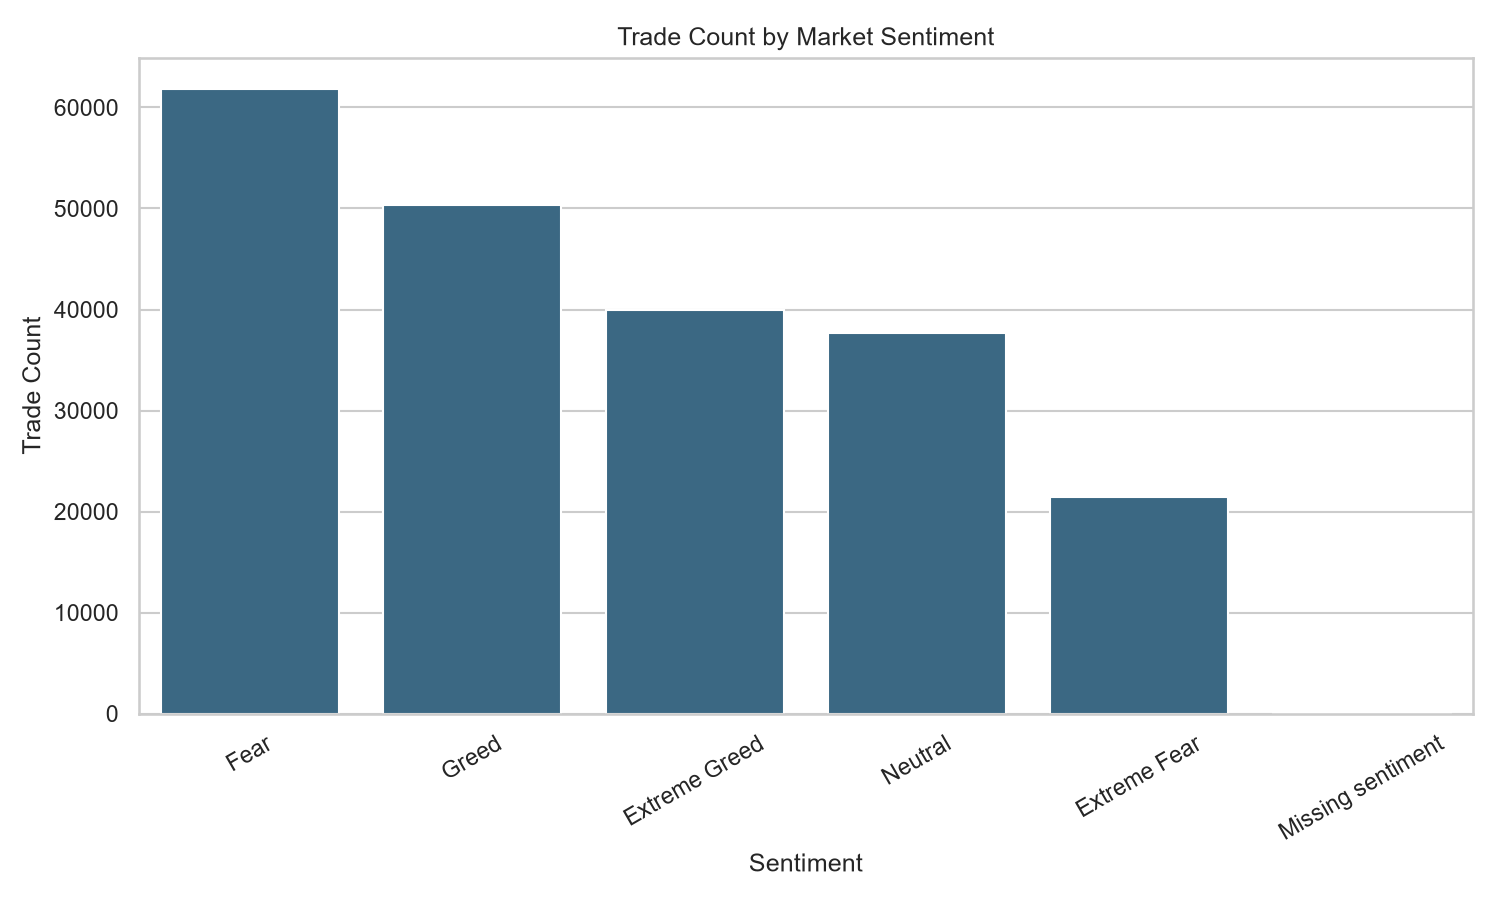

pnl_by_sentiment.png


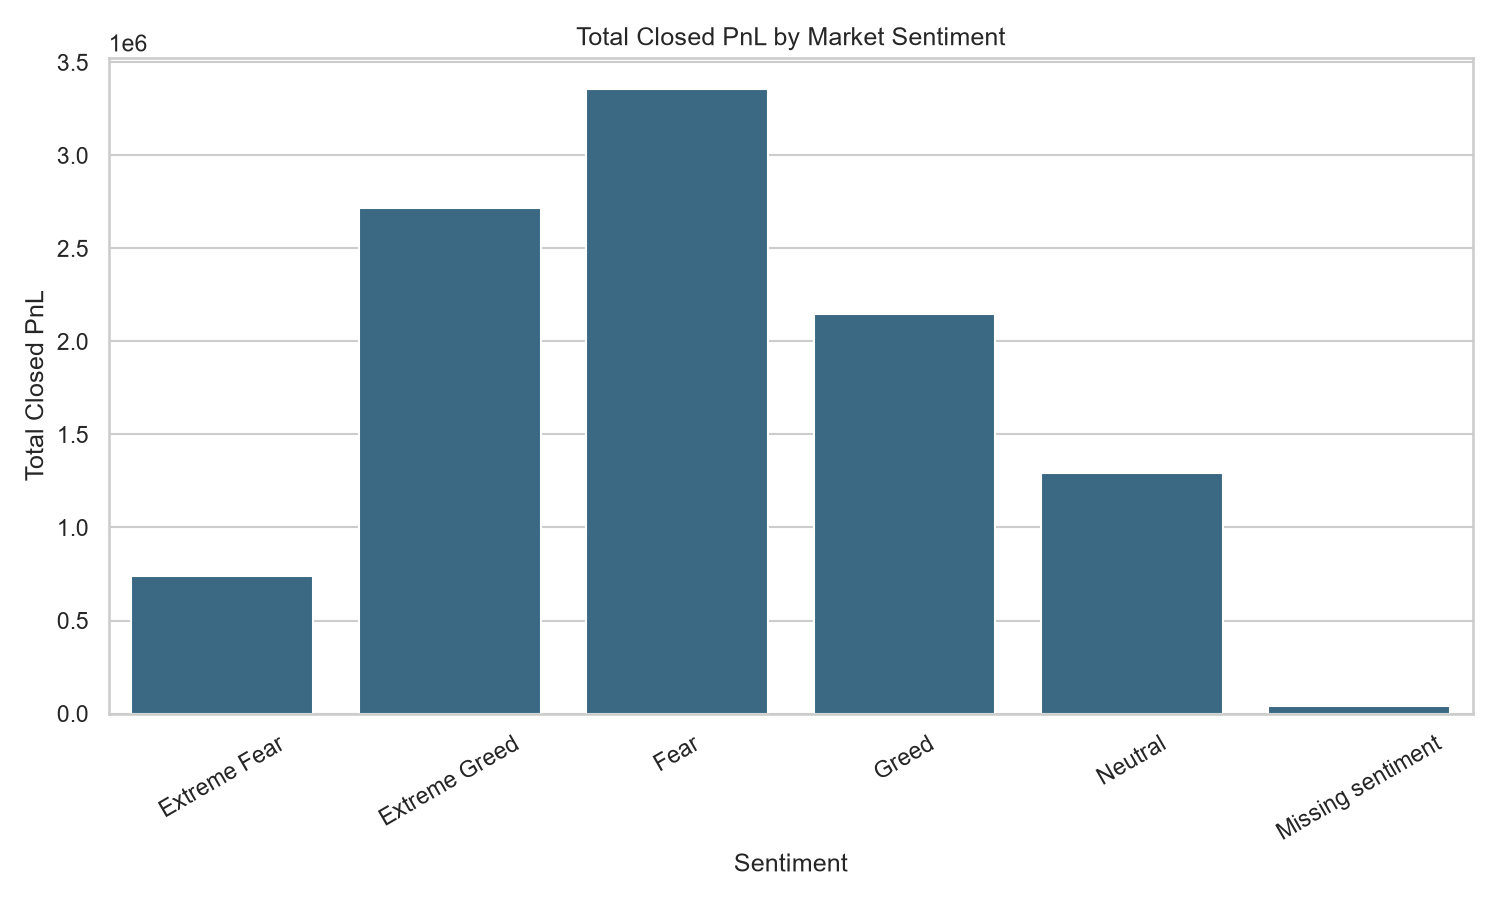

average_pnl_by_sentiment.png


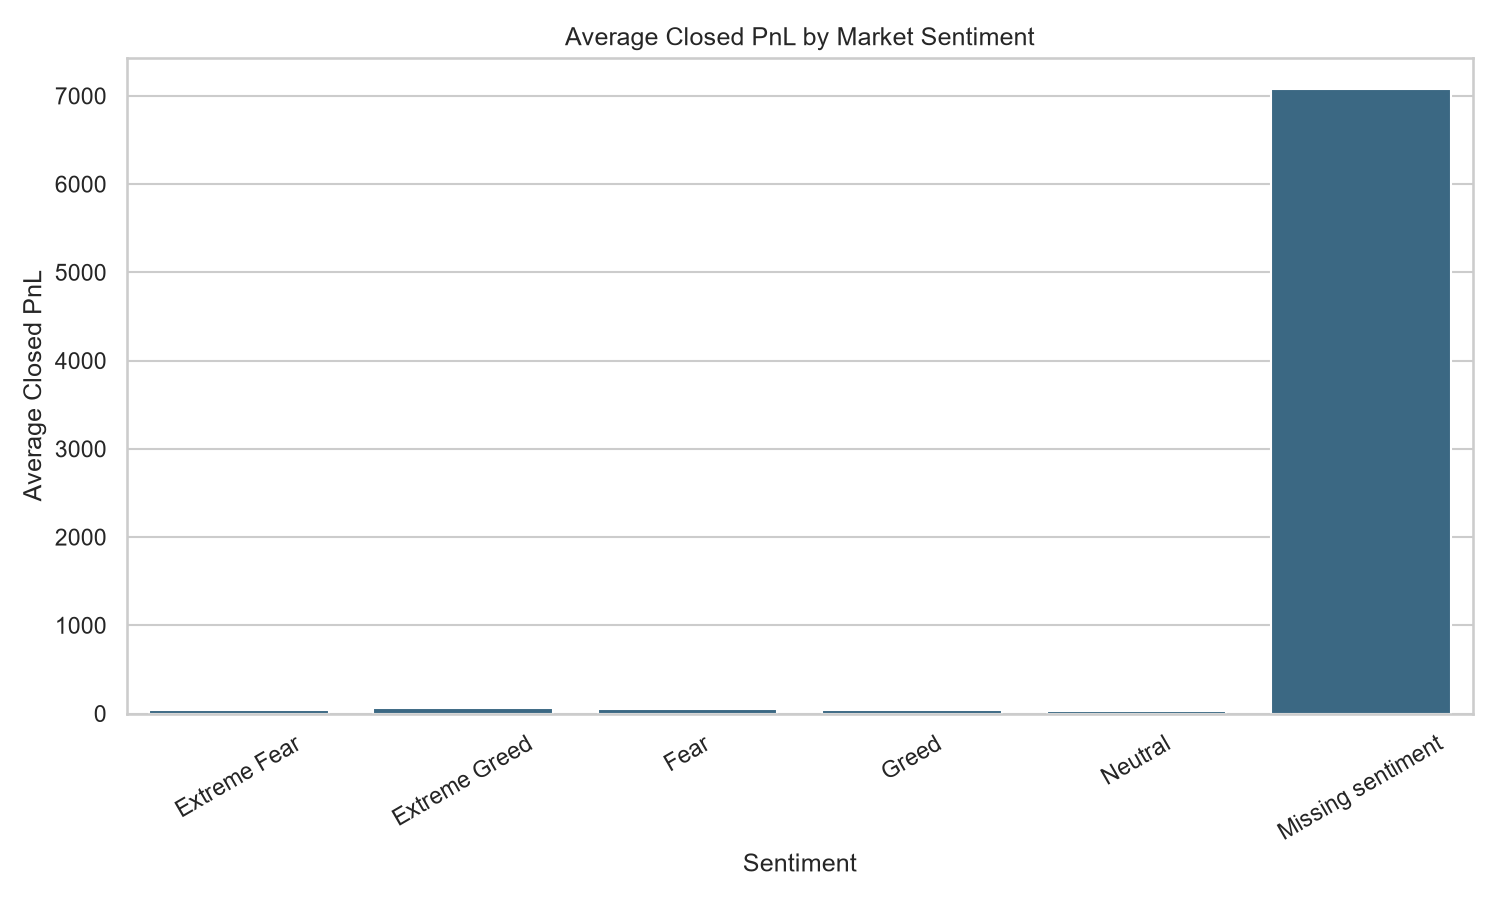

win_rate_by_sentiment.png


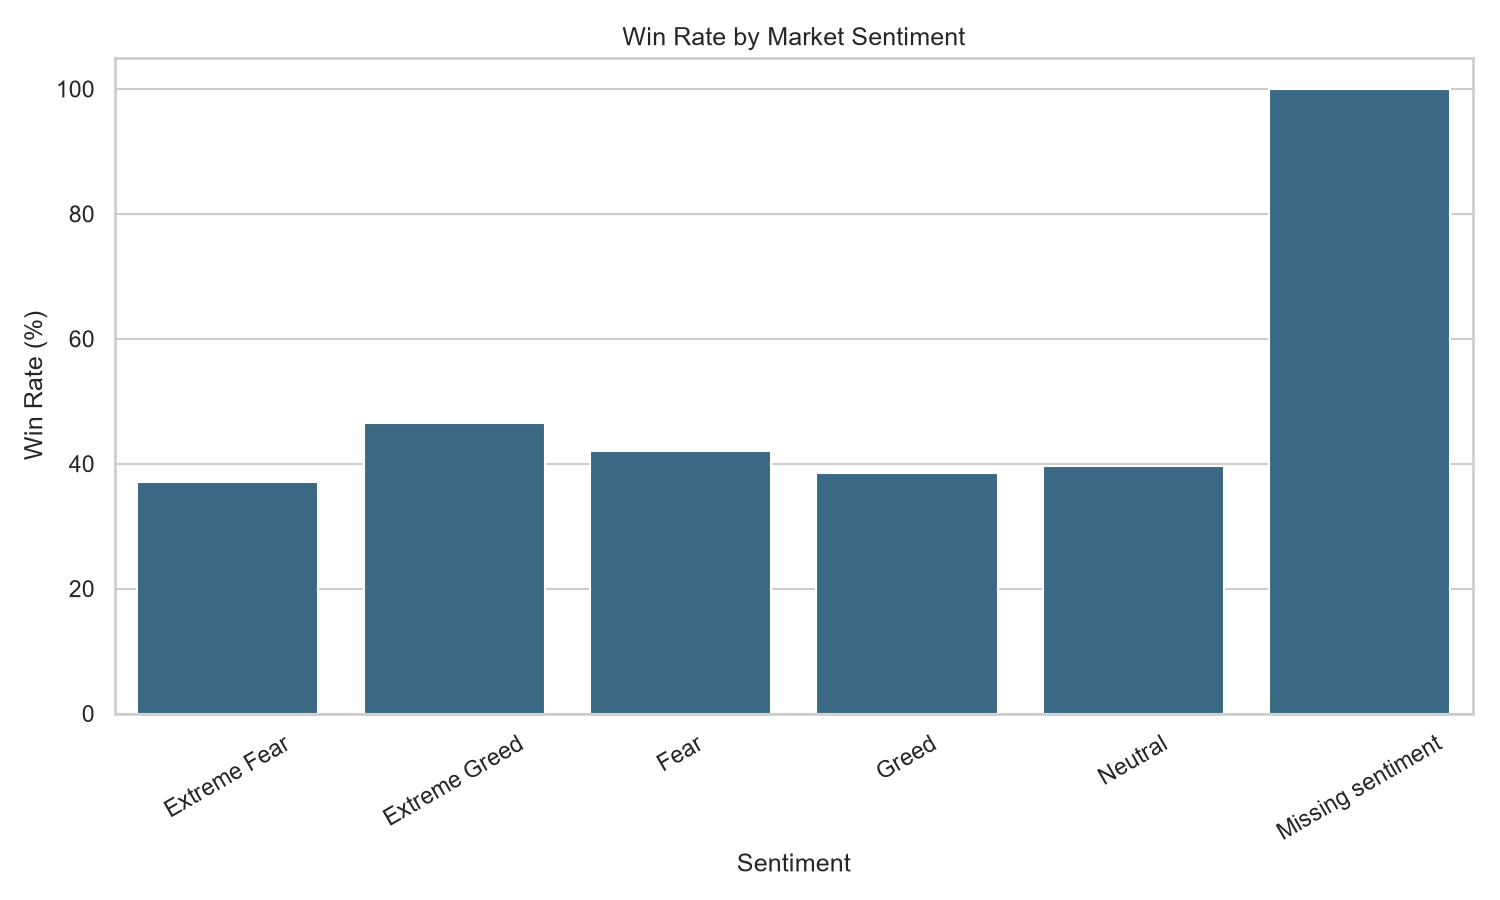

trade_count_by_direction.png


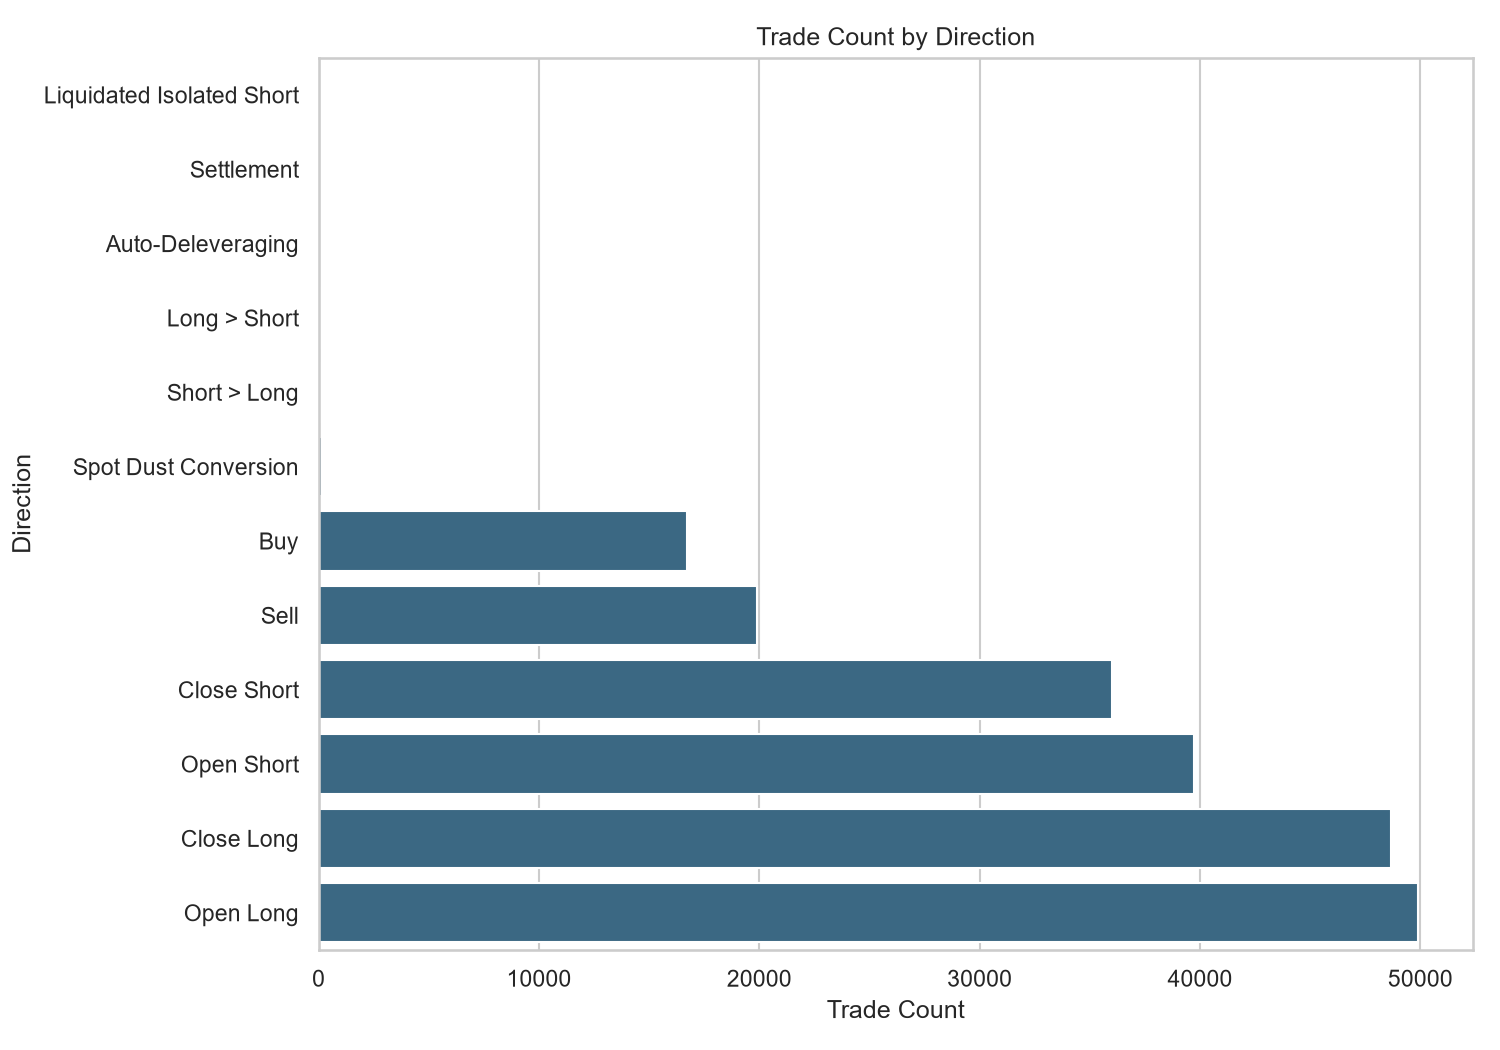

pnl_by_direction.png


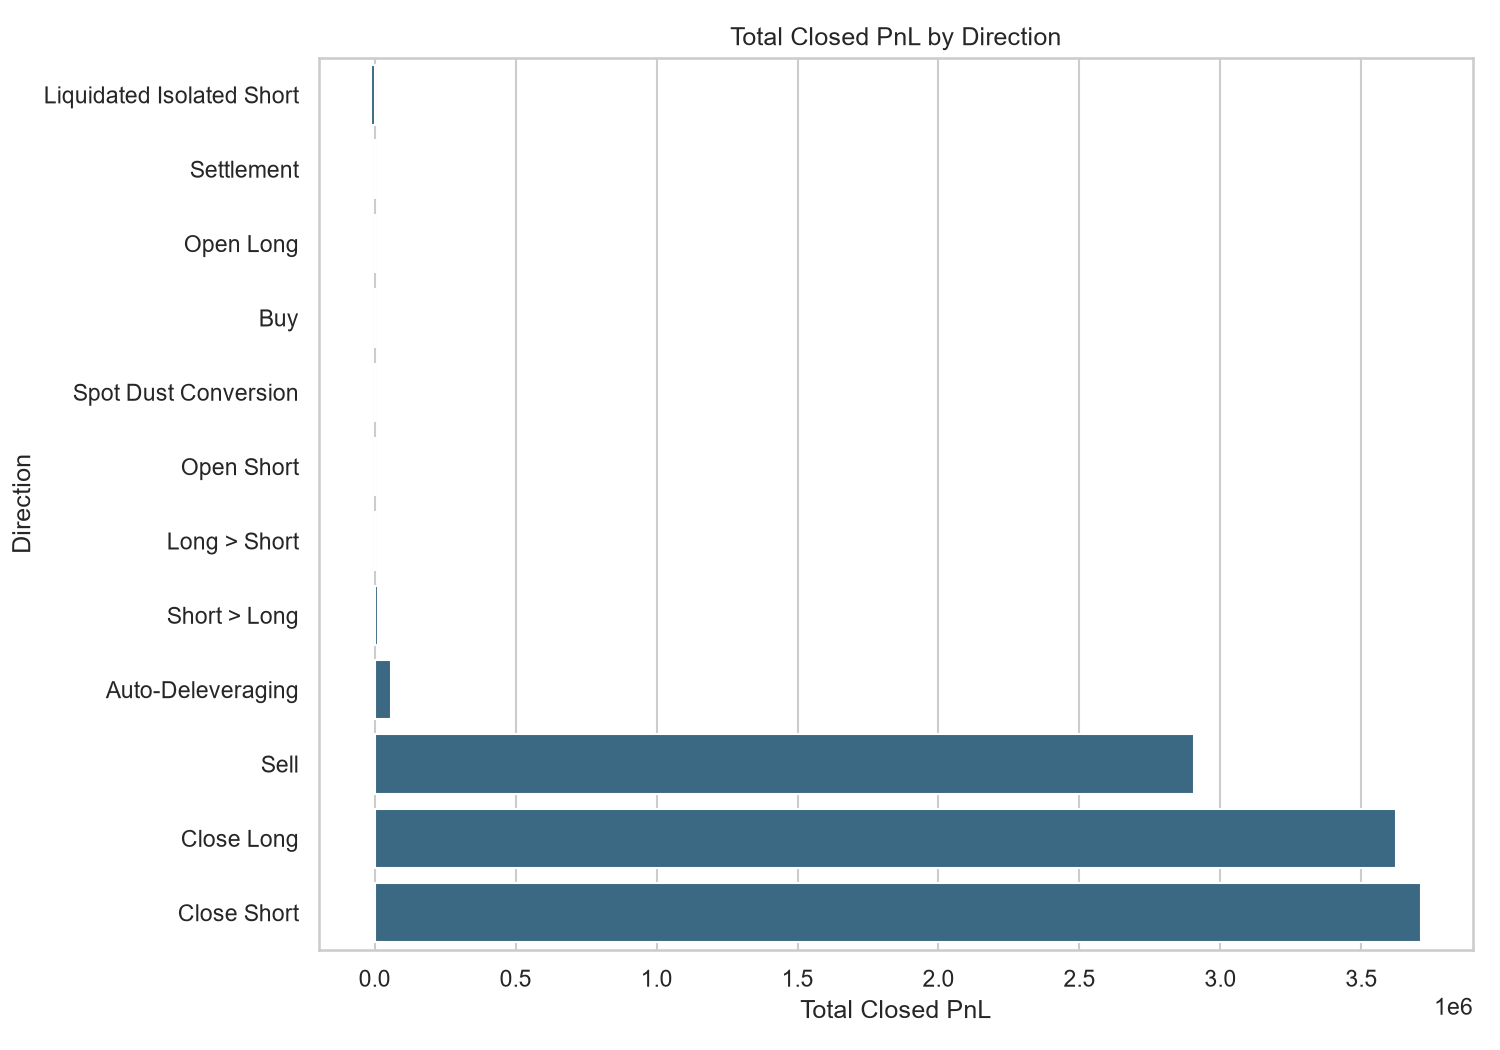

top_coins_by_trade_count.png


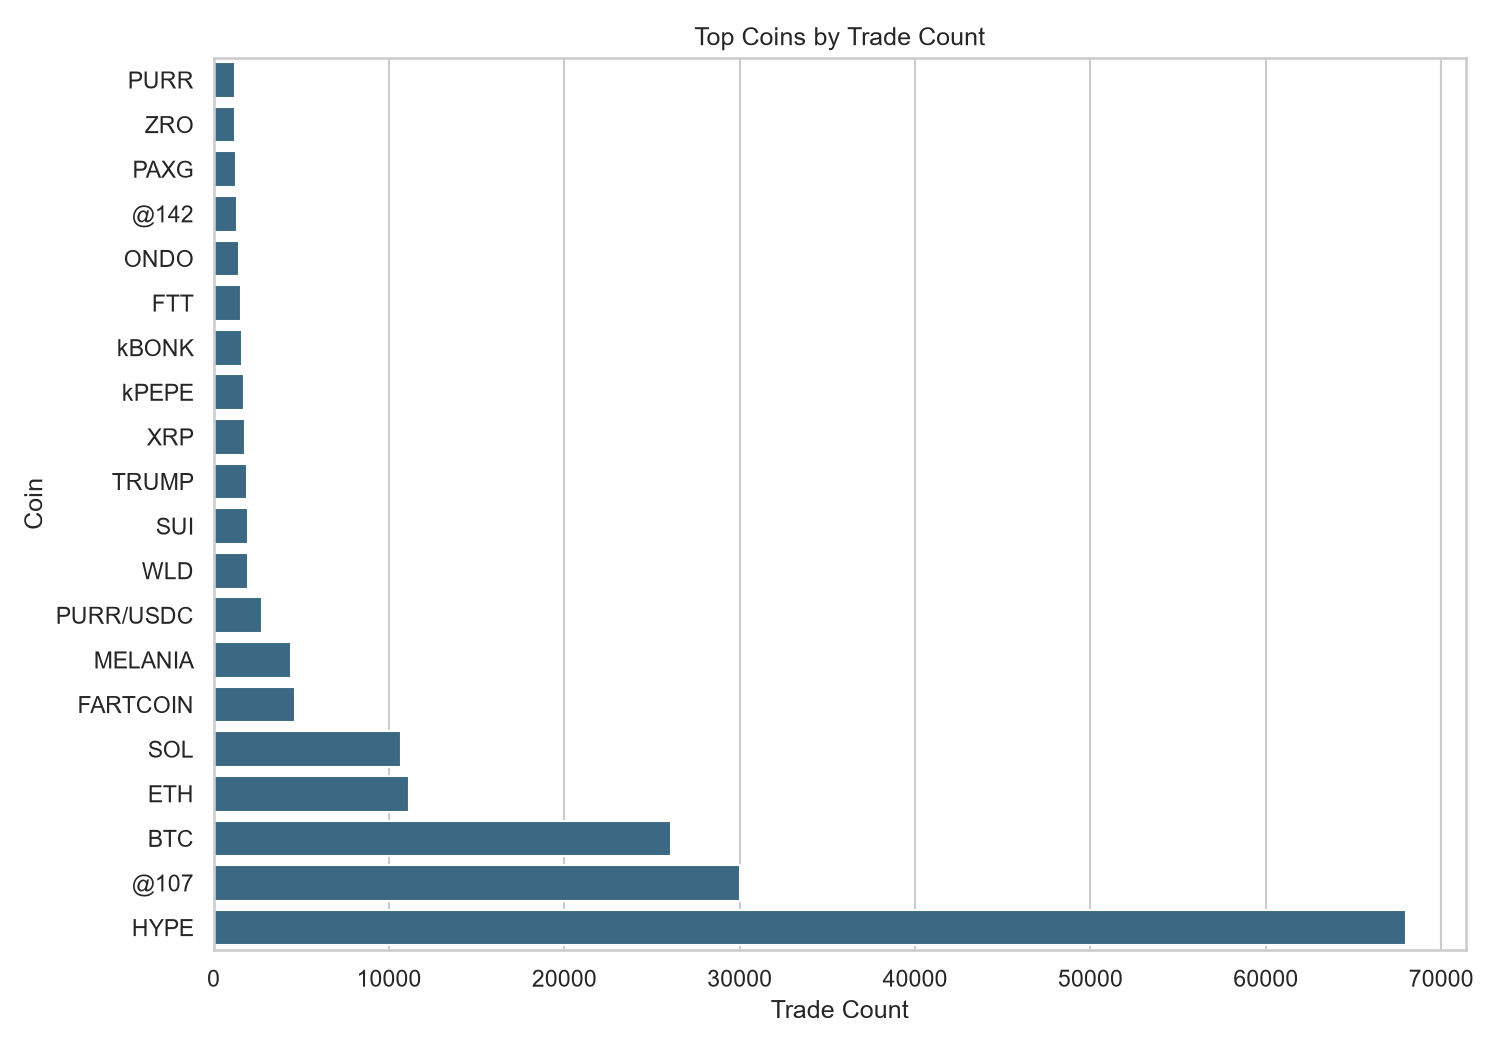

top_coins_by_pnl.png


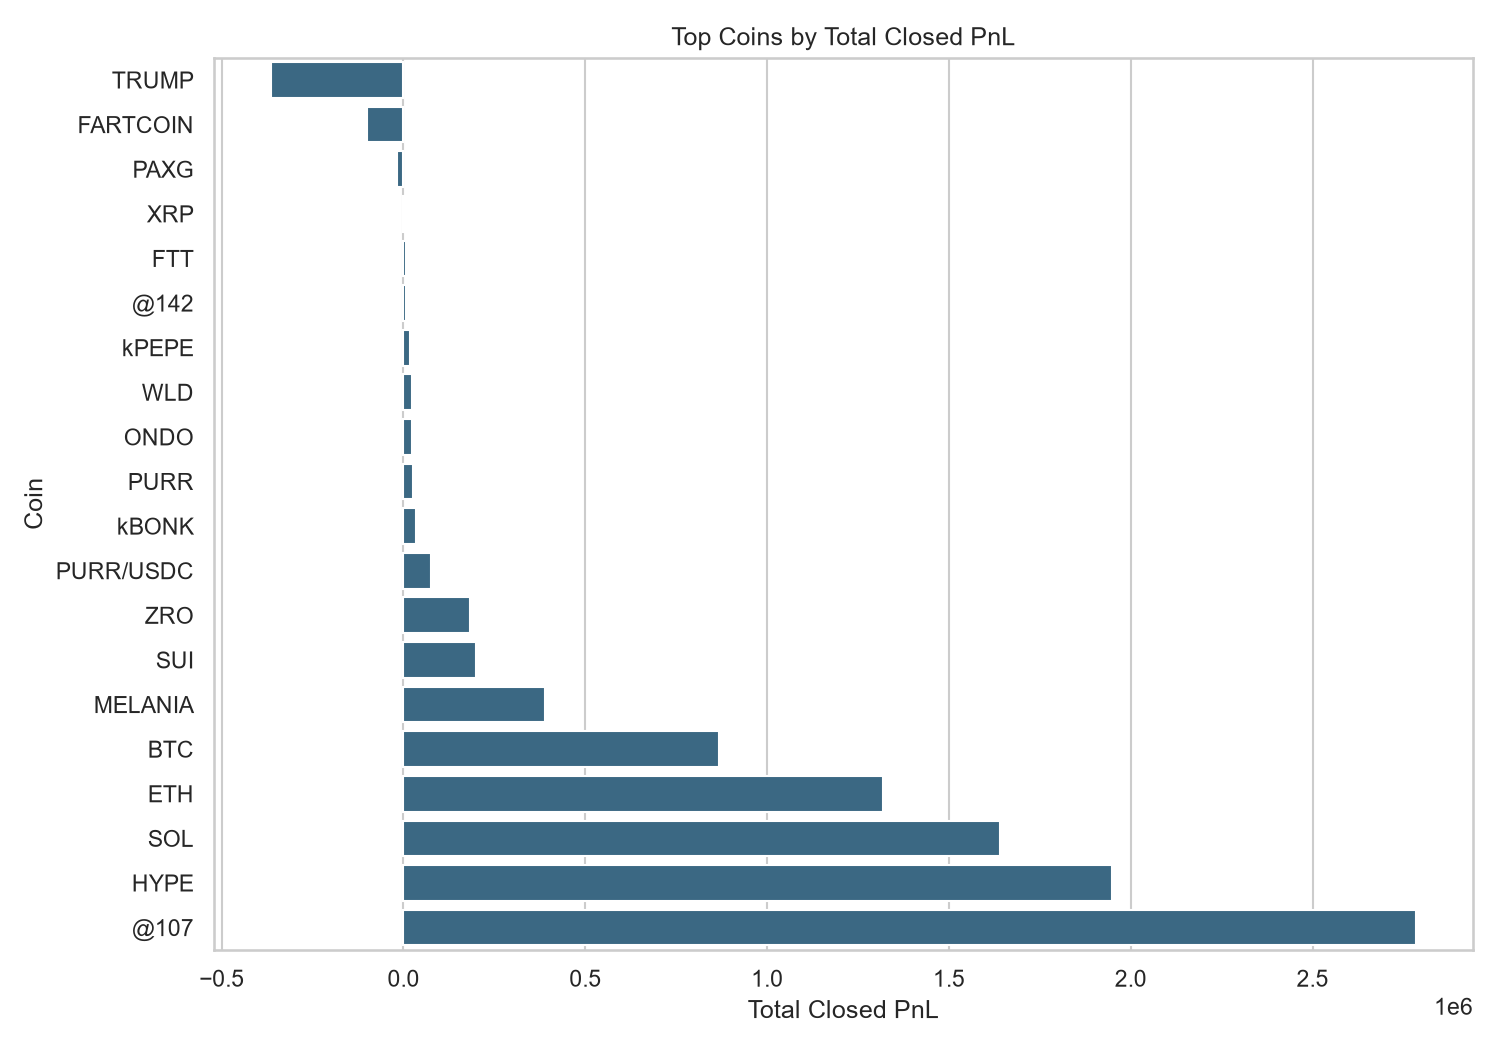

closed_pnl_distribution.png


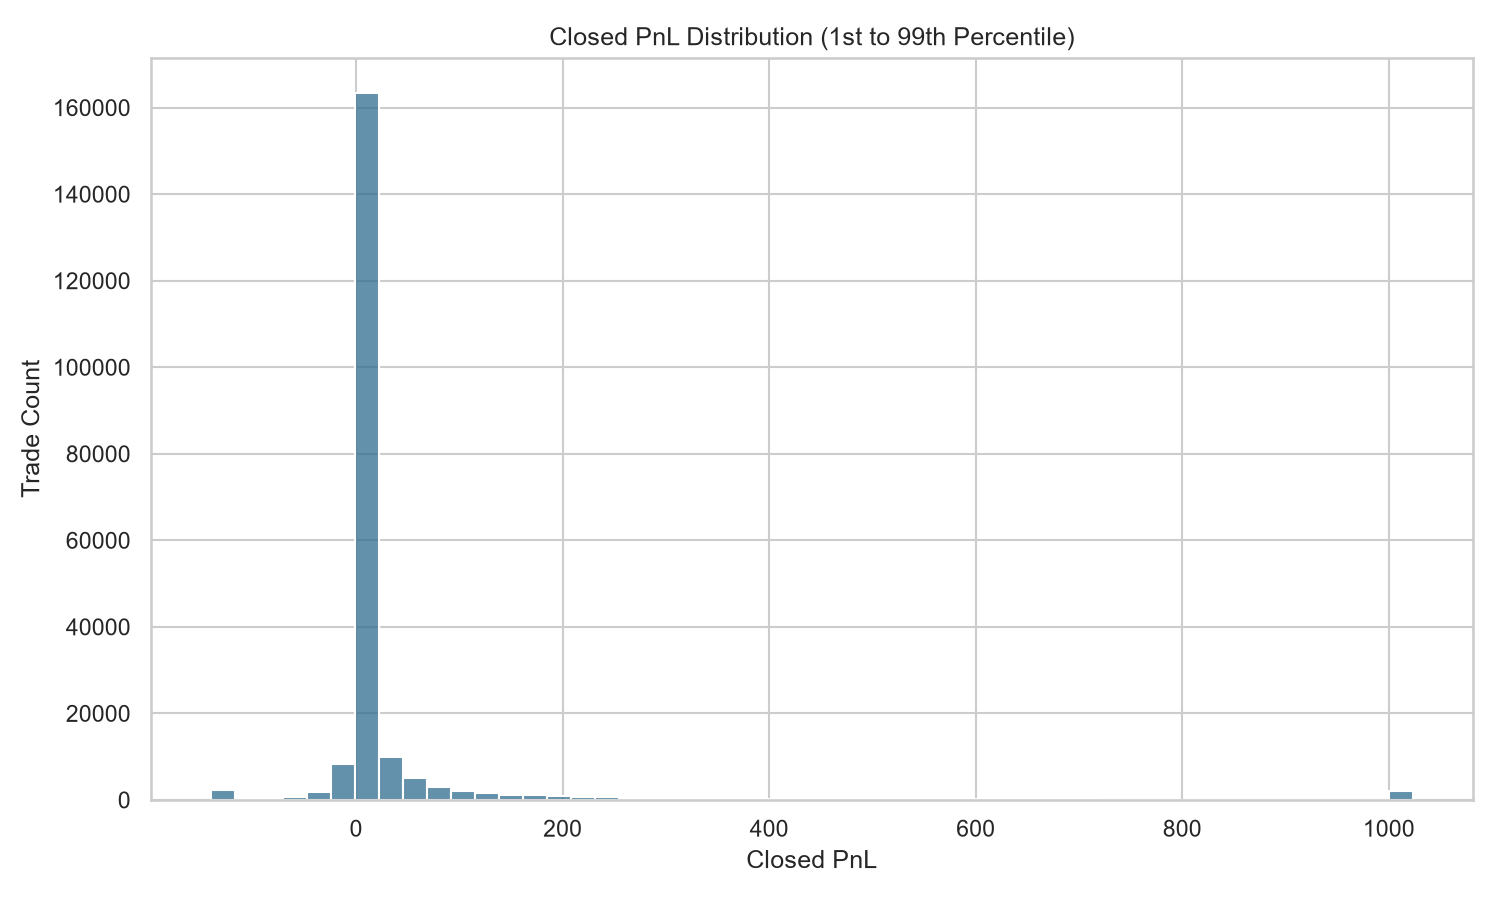

In [47]:
for chart_path in chart_paths:
    print(chart_path.name)
    display(Image(filename=str(chart_path)))

## Phase 6 Notes

At this stage:

- Visual analysis charts have been created.
- Chart PNG files have been saved in `outputs/charts/`.
- The charts use the merged dataset and Phase 5 report tables.
- Raw datasets have not been modified.
- No dashboard, models or final conclusions have been created.

# Phase 8: Final Insights and Report

In this phase, the project outputs are summarized in a final written report.

The report contains descriptive findings only. It does not provide financial advice or trading recommendations.

In [48]:
FINAL_REPORT_PATH = PROJECT_ROOT / "outputs" / "reports" / "final_project_report.md"

print(f"Final report path: {FINAL_REPORT_PATH.resolve()}")
print(f"Final report exists: {FINAL_REPORT_PATH.exists()}")

Final report path: C:\Users\ASUS\Documents\Bitcoin trader sentiment  analysis\bitcoin-trader-sentiment-analysis\outputs\reports\final_project_report.md
Final report exists: True


In [49]:
from IPython.display import Markdown, display

report_text = FINAL_REPORT_PATH.read_text(encoding="utf-8")
preview_text = "\n".join(report_text.splitlines()[:80])
display(Markdown(preview_text))

# Bitcoin Market Sentiment and Trader Performance Analysis

## Final Project Report

## Project Objective

The objective of this project is to analyse the relationship between Bitcoin market sentiment and trader performance.

The project combines historical trading data from Hyperliquid with the Bitcoin Fear and Greed Index. The analysis focuses on trader profitability, win rate, trade direction, traded coins, fees, trade size, and market sentiment conditions.

## Data Used

The project uses two raw datasets:

- `historical_data.csv`
- `fear_greed_index.csv`

The final analysis uses the merged processed dataset:

```text
data/processed/trader_sentiment_merged.csv
```

The merged dataset contains trader data joined with daily Fear and Greed sentiment information.

## Project Workflow Summary

### Phase 1: Project Setup

The project folder structure, notebook, source files, dashboard placeholder, README, requirements file, and `.gitignore` were created.

### Phase 2: Dataset Loading and Inspection

Both raw datasets were loaded and inspected. Column names, data types, missing values, duplicate rows, and categorical values were reviewed.

### Phase 3: Data Cleaning and Preparation

Cleaned copies of both datasets were created and saved in `data/processed/`. Raw datasets were not modified.

### Phase 4: Dataset Merging

The cleaned trader dataset was merged with the cleaned sentiment dataset by trade date.

The final merged dataset contains:

- 211,224 rows
- 21 columns
- Sentiment value and sentiment classification for each matched trade date

There were 6 rows without matching sentiment data, all on `2024-10-26`.

### Phase 5: Exploratory Data Analysis

Summary report CSV files were generated in:

```text
outputs/reports/
```

The reports include overall performance, sentiment-level summaries, direction-level summaries, coin-level summaries, and missing sentiment checks.

### Phase 6: Visual Analysis

Visual charts were generated and saved in:

```text
outputs/charts/
```

The charts cover sentiment distribution, PnL by sentiment, win rate by sentiment, direction summaries, top coins, and Closed PnL distribution.

### Phase 7: Streamlit Dashboard

A local Streamlit dashboard was created in:

```text
dashboard/app.py
```

The dashboard displays metrics, filters, summary tables, charts, missing sentiment warnings, and a filtered data preview.

## Phase 8 Notes

At this stage:

- The final project report has been created.
- The report summarizes the data workflow, EDA results, charts, dashboard, limitations and conclusion.
- Raw datasets have not been modified.
- No model training, deployment, or additional phase work has been performed.